In [19]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from NeuralNetwork import NeuralNetwork, Dense, Tanh, ReLU, Softmax

In [6]:
data = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
data.data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [7]:
X = data.data
X = X / 255.0
y = data.target


Label: 4



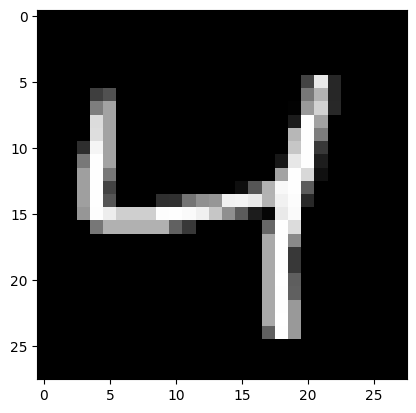

In [8]:
def display_image(index, X, y):
    print(f'\nLabel: {y[index]}\n')
    image = X[index].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.show()

display_image(2, X, y)

In [20]:
X = X.reshape(70000, 784, 1)
NN = NeuralNetwork(None)
y_one_hot = NN.one_hot_encode(y)

In [21]:
X.shape, y_one_hot.shape

((70000, 784, 1), (70000, 10, 1))

In [32]:
X_train = X[:50000]
X_test = X[50000:]
y_train = y_one_hot[:50000]
y_test_norm = y[50000:]
y_test = y_one_hot[50000:]

In [39]:
NN = NeuralNetwork([
    Dense(784, 64),
    ReLU(),
    Dense(64, 32),
    ReLU(),
    Dense(32, 16),
    Tanh(),
    Dense(16, 10),
    Softmax(),
])

In [40]:
NN.train(X_train, y_train, learning_rate=.001, epoch=16, batch_size=100)

Epoch: 1/16 | Cross Entropy Loss: 0.5086922870958713 | Accuracy: 0.87146
Epoch: 2/16 | Cross Entropy Loss: 0.17955486319126768 | Accuracy: 0.95172
Epoch: 3/16 | Cross Entropy Loss: 0.1254870688747563 | Accuracy: 0.96568
Epoch: 4/16 | Cross Entropy Loss: 0.09540693067528579 | Accuracy: 0.97392
Epoch: 5/16 | Cross Entropy Loss: 0.07938642332983954 | Accuracy: 0.97722
Epoch: 6/16 | Cross Entropy Loss: 0.06881497614663509 | Accuracy: 0.97954
Epoch: 7/16 | Cross Entropy Loss: 0.05517131928788359 | Accuracy: 0.98418
Epoch: 8/16 | Cross Entropy Loss: 0.04951102008889457 | Accuracy: 0.98522
Epoch: 9/16 | Cross Entropy Loss: 0.042095699071799934 | Accuracy: 0.98774
Epoch: 10/16 | Cross Entropy Loss: 0.03915153729523734 | Accuracy: 0.98846
Epoch: 11/16 | Cross Entropy Loss: 0.03284938980043736 | Accuracy: 0.99084
Epoch: 12/16 | Cross Entropy Loss: 0.029095551638701728 | Accuracy: 0.99144
Epoch: 13/16 | Cross Entropy Loss: 0.02563029323878098 | Accuracy: 0.99284
Epoch: 14/16 | Cross Entropy Loss:

In [25]:
def display_image_prediction(index, X, y, network):
    output = network.predict(X[index])
    print(f'\nLabel: {y[index]} | Predicted: {np.argmax(output)}\n')
    image = X[index].reshape(28, 28)
    plt.imshow(image)
    plt.show()


Label: 3 | Predicted: 3



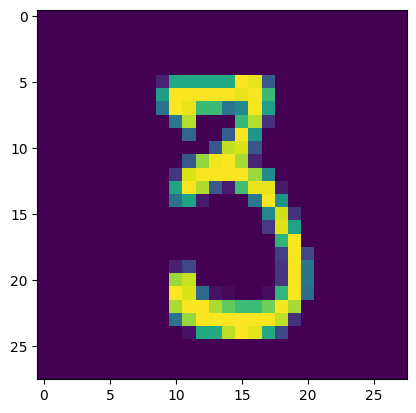

In [26]:
display_image_prediction(43, X_test, y_test_norm, NN)

In [30]:
def show_incorrect(X, y, network, limit):
    X_sq = X.squeeze(-1).T
    y_sq = y.squeeze(-1).T
    
    output = network.predict(X_sq)
    preds = np.argmax(output, axis=0)
    labels = np.argmax(y_sq, axis=0)
    
    incorrect = np.where(preds != labels)
    for i in incorrect[0][:limit]:
        display_image_prediction(i, X, np.argmax(y, axis=1), network)
    return incorrect


Label: [6] | Predicted: 2



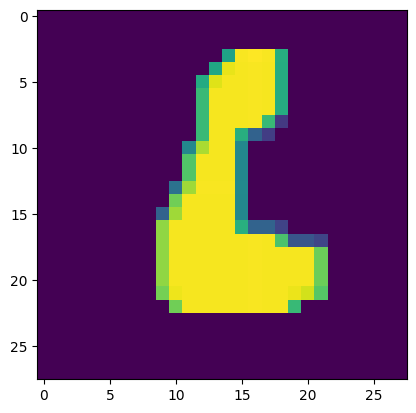


Label: [5] | Predicted: 2



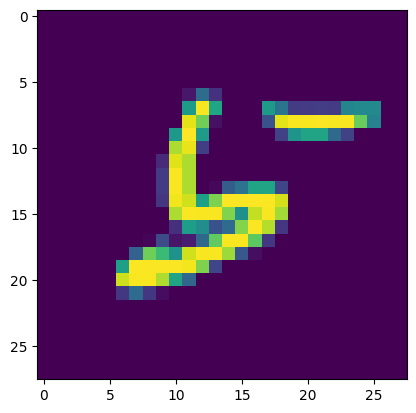


Label: [2] | Predicted: 3



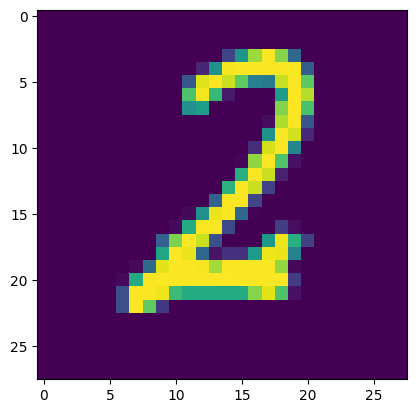


Label: [3] | Predicted: 8



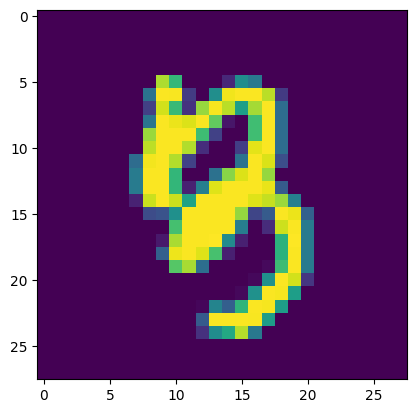


Label: [9] | Predicted: 0



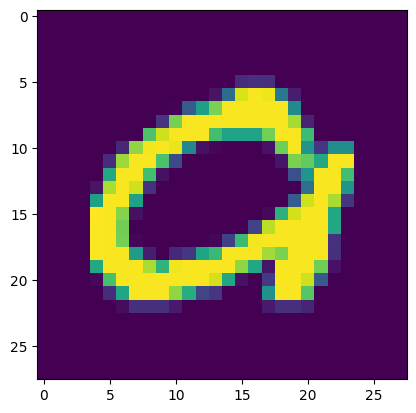


Label: [8] | Predicted: 3



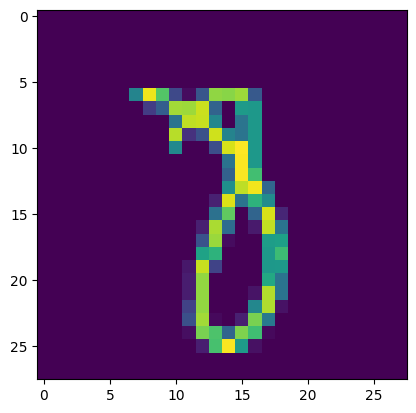


Label: [3] | Predicted: 2



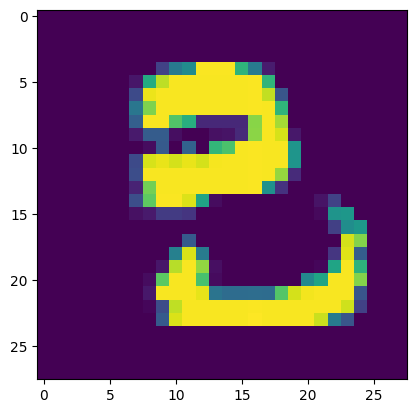


Label: [9] | Predicted: 7



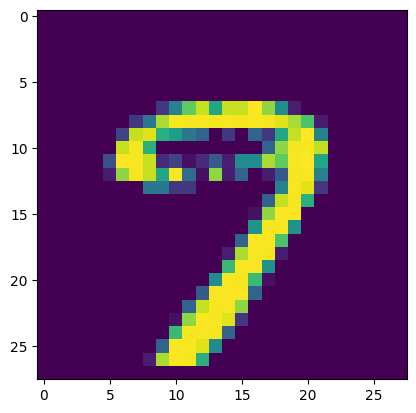


Label: [3] | Predicted: 2



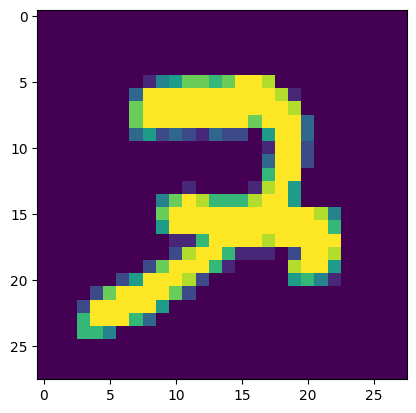


Label: [8] | Predicted: 5



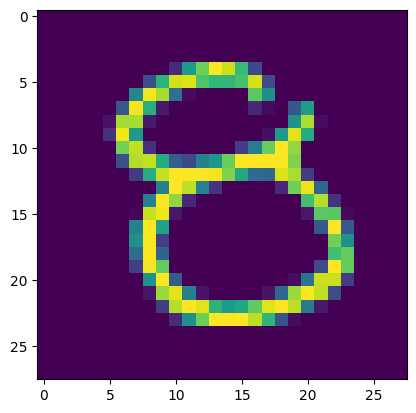

(array([   86,    91,   167,   212,   239,   246,   317,   329,   340,
          342,   355,   369,   391,   403,   408,   417,   428,   431,
          446,   462,   500,   514,   522,   560,   572,   574,   632,
          714,   747,   773,   826,   881,   916,   917,   930,   957,
         1081,  1104,  1180,  1230,  1248,  1274,  1280,  1300,  1337,
         1346,  1398,  1414,  1442,  1544,  1600,  1698,  1740,  1764,
         1794,  1863,  1944,  1945,  1987,  1988,  2048,  2086,  2117,
         2129,  2138,  2140,  2160,  2163,  2210,  2218,  2241,  2246,
         2280,  2324,  2394,  2424,  2610,  2661,  2674,  2707,  2800,
         2808,  2854,  2927,  2932,  2938,  2953,  2968,  2971,  2975,
         2981,  3017,  3019,  3044,  3063,  3156,  3216,  3470,  3476,
         3492,  3507,  3570,  3578,  3580,  3638,  3641,  3680,  3693,
         3694,  3784,  3806,  3854,  3872,  3873,  3903,  3906,  3999,
         4006,  4030,  4036,  4074,  4097,  4178,  4191,  4195,  4264,
      

In [31]:
show_incorrect(X_test, y_test, NN, 10)